In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# ============================================
# CONFIGURATION
# ============================================
base_path = "Smoking.v3i.yolov8"   # Update if needed
splits = ['train', 'valid', 'test']
class_name = 'smoking'   # only one class after removal


In [2]:

# ============================================
# HELPER FUNCTIONS
# ============================================
def parse_yolo_label(label_path, img_w, img_h):
    """Parse YOLO label file and return absolute coordinates."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            class_id = int(parts[0])
            x_center = float(parts[1]) * img_w
            y_center = float(parts[2]) * img_h
            width = float(parts[3]) * img_w
            height = float(parts[4]) * img_h
            x1 = int(x_center - width/2)
            y1 = int(y_center - height/2)
            x2 = int(x_center + width/2)
            y2 = int(y_center + height/2)
            boxes.append((class_id, x1, y1, x2, y2, width, height))
    return boxes


SMOKING DATASET ANALYSIS

📂 Analyzing TRAIN...
   Images: 6783
   Label files: 3378
   Missing labels: 3405
   Missing images: 0
   Total 'smoking' boxes: 4197
   Avg boxes per image: 0.62

📂 Analyzing VALID...
   Images: 993
   Label files: 592
   Missing labels: 401
   Missing images: 0
   Total 'smoking' boxes: 743
   Avg boxes per image: 0.75

📂 Analyzing TEST...
   Images: 454
   Label files: 253
   Missing labels: 201
   Missing images: 0
   Total 'smoking' boxes: 298
   Avg boxes per image: 0.66


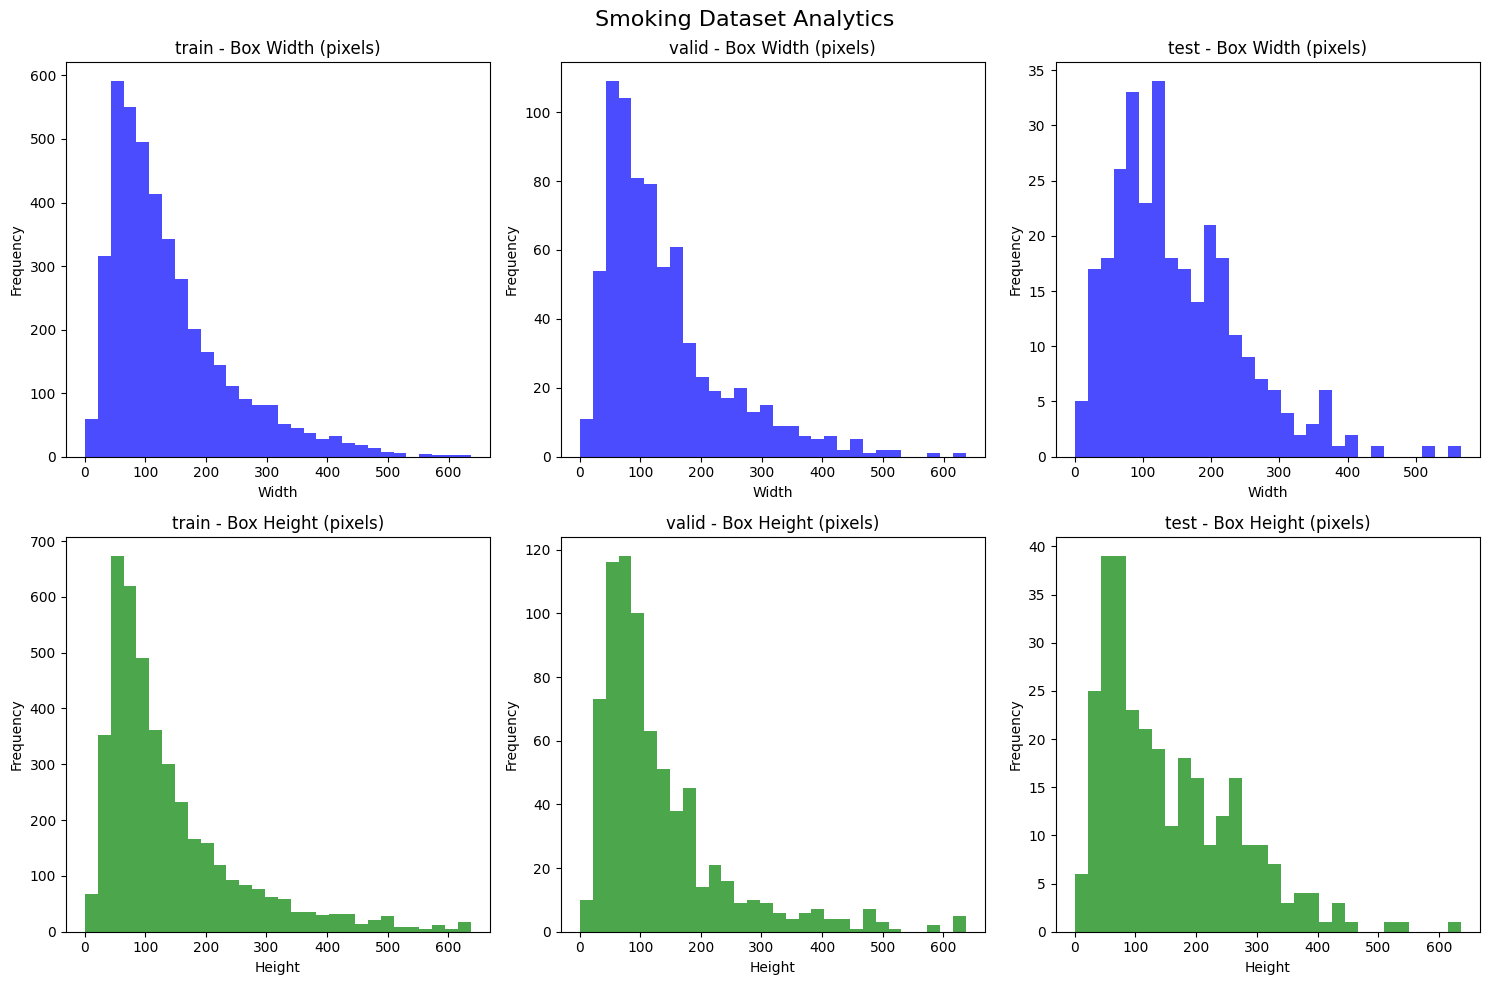

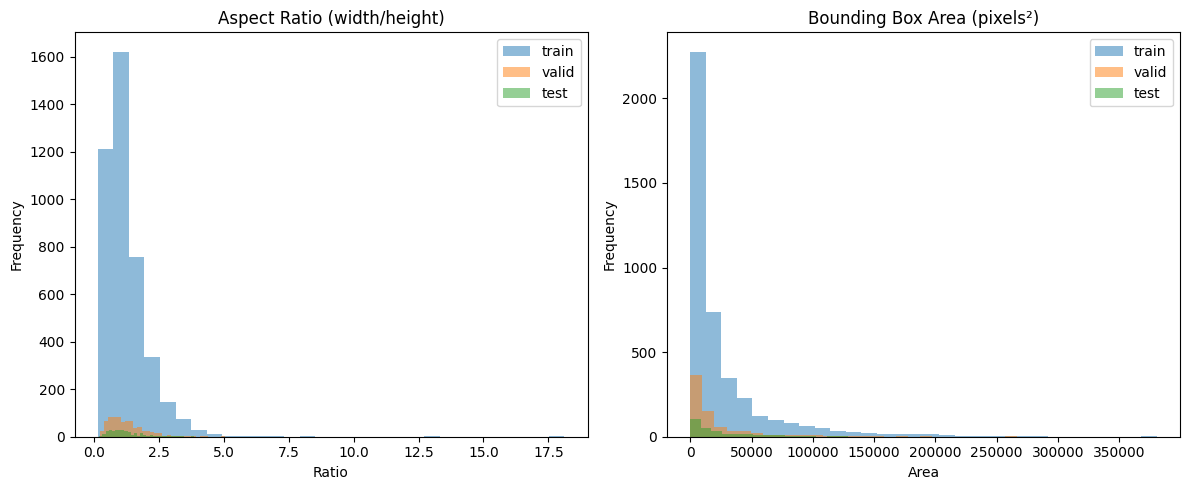

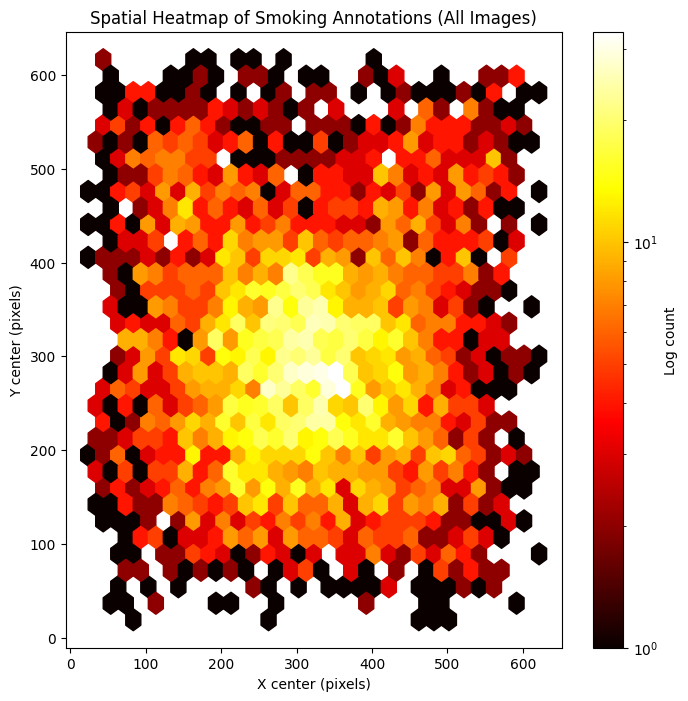

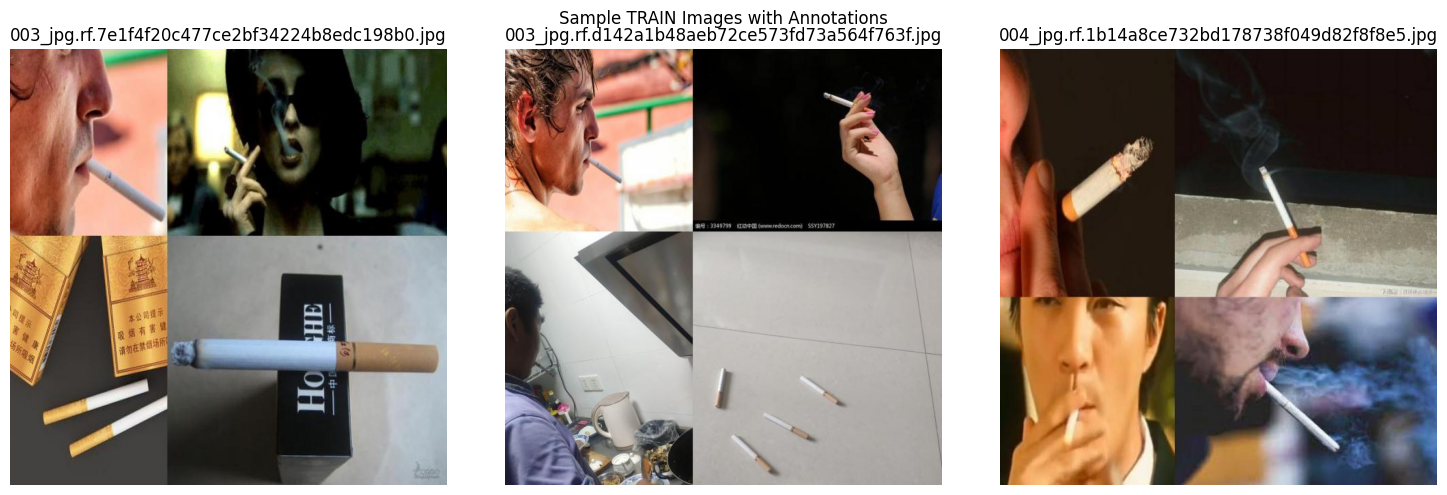

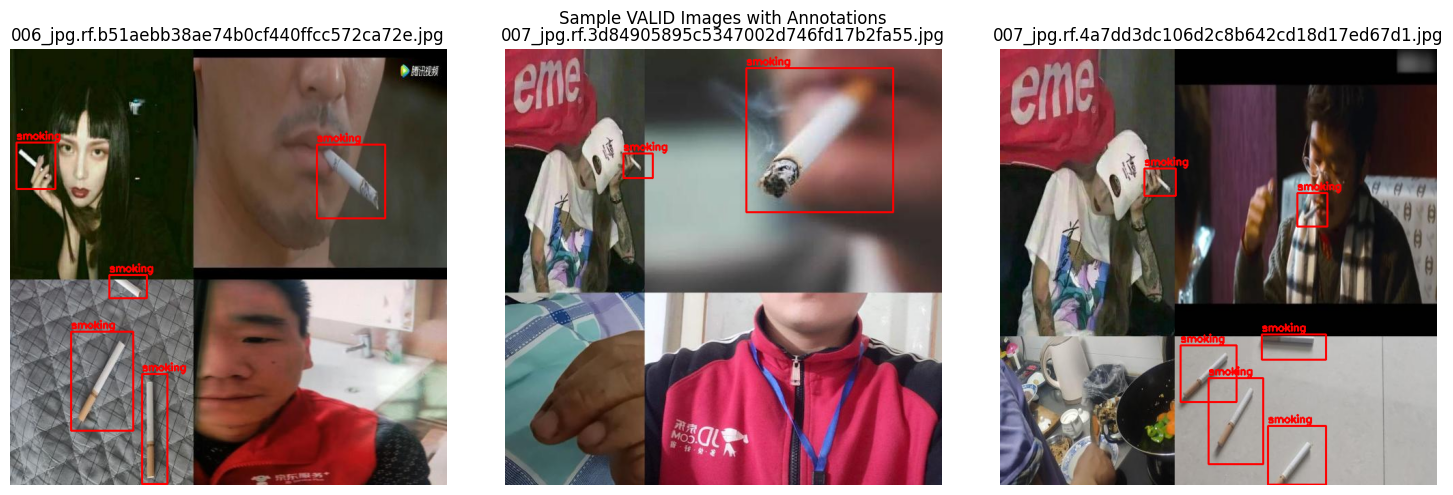

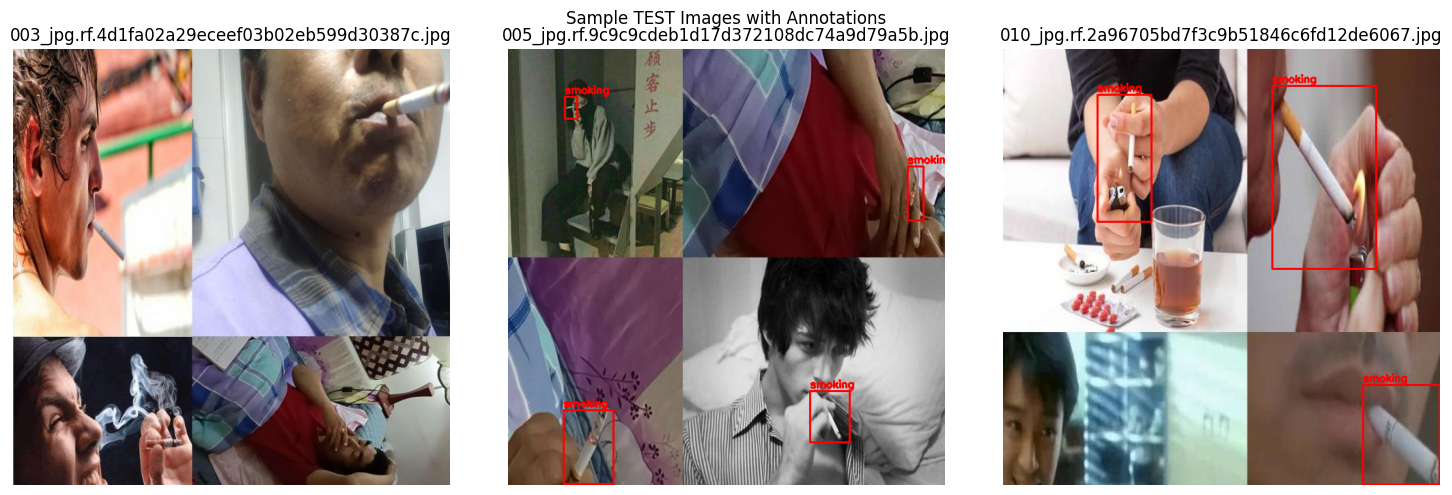

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# ============================================
# CONFIGURATION
# ============================================
base_path = Path("Smoking.v3i.yolov8")   # Use Path object
splits = ['train', 'valid', 'test']
class_name = 'smoking'

# ============================================
# HELPER FUNCTIONS
# ============================================
def parse_yolo_label(label_path, img_w, img_h):
    """Parse YOLO label file and return absolute coordinates."""
    boxes = []
    if not Path(label_path).exists():
        return boxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            class_id = int(parts[0])
            x_center = float(parts[1]) * img_w
            y_center = float(parts[2]) * img_h
            width = float(parts[3]) * img_w
            height = float(parts[4]) * img_h
            x1 = int(x_center - width/2)
            y1 = int(y_center - height/2)
            x2 = int(x_center + width/2)
            y2 = int(y_center + height/2)
            boxes.append((class_id, x1, y1, x2, y2, width, height))
    return boxes

def analyze_split(split_path):
    """Analyze one split (train/val/test)."""
    images_dir = split_path / 'images'
    labels_dir = split_path / 'labels'
    
    if not images_dir.exists() or not labels_dir.exists():
        print(f"⚠️ Skipping {split_path}: missing images or labels folder")
        return None
    
    image_files = sorted(images_dir.glob('*.*'))
    label_files = sorted(labels_dir.glob('*.txt'))
    
    n_images = len(image_files)
    n_labels = len(label_files)
    
    image_stems = {f.stem for f in image_files}
    label_stems = {f.stem for f in label_files}
    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems
    
    total_boxes = 0
    widths = []
    heights = []
    areas = []
    aspect_ratios = []
    x_centers = []
    y_centers = []
    
    for label_file in label_files:
        # Try .jpg then .png
        img_file = images_dir / (label_file.stem + '.jpg')
        if not img_file.exists():
            img_file = images_dir / (label_file.stem + '.png')
        if not img_file.exists():
            continue
            
        img = cv2.imread(str(img_file))
        if img is None:
            continue
        h, w = img.shape[:2]
        
        boxes = parse_yolo_label(str(label_file), w, h)
        total_boxes += len(boxes)
        for _, x1, y1, x2, y2, bw, bh in boxes:
            widths.append(bw)
            heights.append(bh)
            areas.append(bw * bh)
            aspect_ratios.append(bw / bh if bh > 0 else 0)
            x_centers.append((x1 + x2) / 2)
            y_centers.append((y1 + y2) / 2)
    
    return {
        'split': split_path.name,
        'n_images': n_images,
        'n_labels': n_labels,
        'missing_labels': len(missing_labels),
        'missing_images': len(missing_images),
        'total_boxes': total_boxes,
        'avg_boxes_per_image': total_boxes / n_images if n_images > 0 else 0,
        'widths': widths,
        'heights': heights,
        'areas': areas,
        'aspect_ratios': aspect_ratios,
        'x_centers': x_centers,
        'y_centers': y_centers
    }

# ============================================
# MAIN ANALYSIS
# ============================================
print("=" * 60)
print("SMOKING DATASET ANALYSIS")
print("=" * 60)

split_stats = []
for split in splits:
    split_path = base_path / split
    if split_path.exists():
        print(f"\n📂 Analyzing {split.upper()}...")
        stats = analyze_split(split_path)
        if stats:
            split_stats.append(stats)
            print(f"   Images: {stats['n_images']}")
            print(f"   Label files: {stats['n_labels']}")
            print(f"   Missing labels: {stats['missing_labels']}")
            print(f"   Missing images: {stats['missing_images']}")
            print(f"   Total 'smoking' boxes: {stats['total_boxes']}")
            print(f"   Avg boxes per image: {stats['avg_boxes_per_image']:.2f}")
    else:
        print(f"⚠️ Split folder not found: {split_path}")

# If nothing found, print current directory contents
if not split_stats:
    print("\n❌ No data found. Check that 'Smoking.v3i.yolov8' exists in the current directory.")
    print("Current working directory:", Path.cwd())
    print("Contents:", list(Path.cwd().iterdir()))
else:
    # ============================================
    # VISUALIZATION: Box Size Distribution
    # ============================================
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle("Smoking Dataset Analytics", fontsize=16)

    for idx, stats in enumerate(split_stats):
        split_name = stats['split']
        axes[0, idx].hist(stats['widths'], bins=30, alpha=0.7, color='blue')
        axes[0, idx].set_title(f"{split_name} - Box Width (pixels)")
        axes[0, idx].set_xlabel("Width")
        axes[0, idx].set_ylabel("Frequency")
        
        axes[1, idx].hist(stats['heights'], bins=30, alpha=0.7, color='green')
        axes[1, idx].set_title(f"{split_name} - Box Height (pixels)")
        axes[1, idx].set_xlabel("Height")
        axes[1, idx].set_ylabel("Frequency")

    for i in range(len(split_stats), 3):
        axes[0, i].axis('off')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

    # ============================================
    # VISUALIZATION: Aspect Ratio & Object Size
    # ============================================
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
    for stats in split_stats:
        split_name = stats['split']
        axes2[0].hist(stats['aspect_ratios'], bins=30, alpha=0.5, label=split_name)
        axes2[1].hist(stats['areas'], bins=30, alpha=0.5, label=split_name)

    axes2[0].set_title("Aspect Ratio (width/height)")
    axes2[0].set_xlabel("Ratio")
    axes2[0].set_ylabel("Frequency")
    axes2[0].legend()

    axes2[1].set_title("Bounding Box Area (pixels²)")
    axes2[1].set_xlabel("Area")
    axes2[1].set_ylabel("Frequency")
    axes2[1].legend()
    plt.tight_layout()
    plt.show()

    # ============================================
    # VISUALIZATION: Spatial Distribution (Heatmap)
    # ============================================
    all_x = []
    all_y = []
    for stats in split_stats:
        all_x.extend(stats['x_centers'])
        all_y.extend(stats['y_centers'])

    if all_x and all_y:
        fig3, ax3 = plt.subplots(figsize=(8, 8))
        hb = ax3.hexbin(all_x, all_y, gridsize=30, cmap='hot', bins='log')
        ax3.set_title("Spatial Heatmap of Smoking Annotations (All Images)")
        ax3.set_xlabel("X center (pixels)")
        ax3.set_ylabel("Y center (pixels)")
        plt.colorbar(hb, ax=ax3, label='Log count')
        plt.show()

    # ============================================
    # SAMPLE VISUALIZATION
    # ============================================
    def show_sample_images(split, num_samples=4):
        split_path = base_path / split
        images_dir = split_path / 'images'
        labels_dir = split_path / 'labels'
        
        image_files = sorted(images_dir.glob('*.*'))[:num_samples]
        if not image_files:
            print(f"No images in {split}")
            return
        
        fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
        if num_samples == 1:
            axes = [axes]
        
        for ax, img_file in zip(axes, image_files):
            img = cv2.imread(str(img_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            
            label_file = labels_dir / (img_file.stem + '.txt')
            if label_file.exists():
                boxes = parse_yolo_label(str(label_file), w, h)
                for _, x1, y1, x2, y2, _, _ in boxes:
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, class_name, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)
            
            ax.imshow(img)
            ax.set_title(f"{img_file.name}")
            ax.axis('off')
        
        plt.suptitle(f"Sample {split.upper()} Images with Annotations")
        plt.tight_layout()
        plt.show()

    for split in splits:
        split_path = base_path / split
        if split_path.exists():
            show_sample_images(split, num_samples=3)